<a href="https://colab.research.google.com/github/anagaglory/-social-media-sentiment-analysis/blob/main/Sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('Sentiment_dataset.csv')

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [ ]:
df.info()

df.isnull().sum()

df['Sentiment'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


,count
Sentiment,
Positive,44
Joy,42
Excitement,32
Happy,14
Neutral,14
...,...
Vibrancy,1
Culinary Adventure,1
Mesmerizing,1


In [ ]:
!pip install nltk textblob wordcloud

In [ ]:
import nltk
import re

from nltk.corpus import stopwords
from textblob import TextBlob

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['Clean_Text'] = df['Text'].apply(clean_text)

df[['Text','Clean_Text']].head()

,Text,Clean_Text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight


In [ ]:
def get_polarity(text):
    return TextBlob(text).sentiment.polarity

df['Polarity'] = df['Clean_Text'].apply(get_polarity)

df[['Clean_Text','Polarity']].head()

,Clean_Text,Polarity
0,enjoying beautiful day park,0.675000
1,traffic terrible morning,-1.000000
2,finished amazing workout,0.600000
3,excited upcoming weekend getaway,0.375000
4,trying new recipe dinner tonight,0.136364


In [ ]:
def classify_sentiment(score):

    if score > 0:
        return 'Positive'

    elif score < 0:
        return 'Negative'

    else:
        return 'Neutral'

df['Predicted_Sentiment'] = df['Polarity'].apply(classify_sentiment)

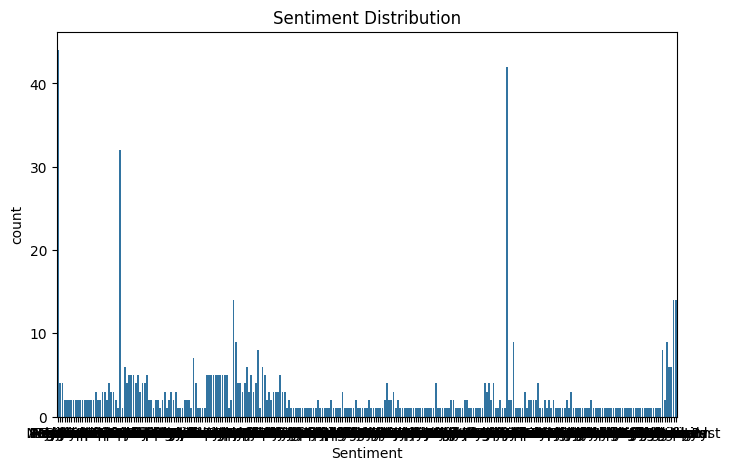

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df
)

plt.title('Sentiment Distribution')

plt.show()

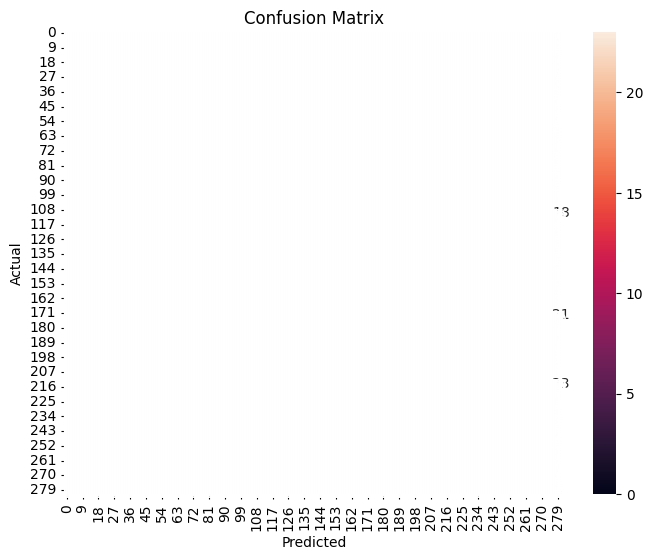

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df['Sentiment'],
    df['Predicted_Sentiment']
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

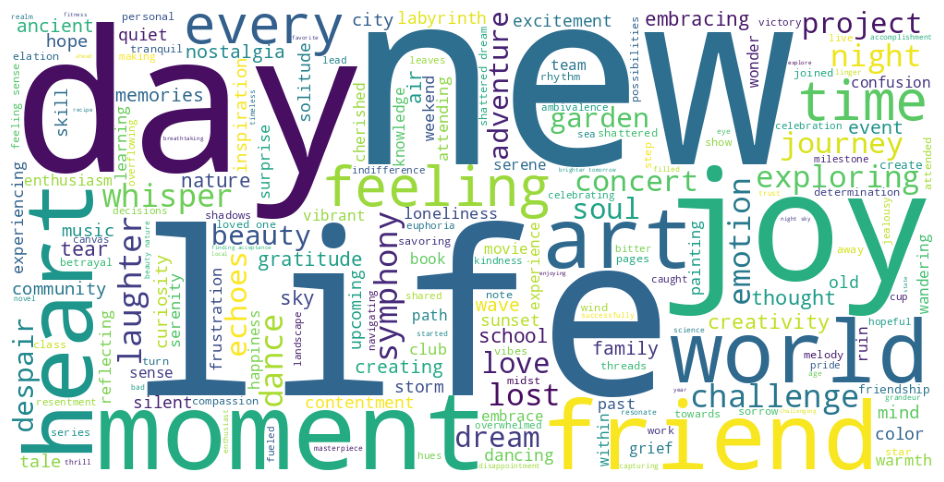

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['Clean_Text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

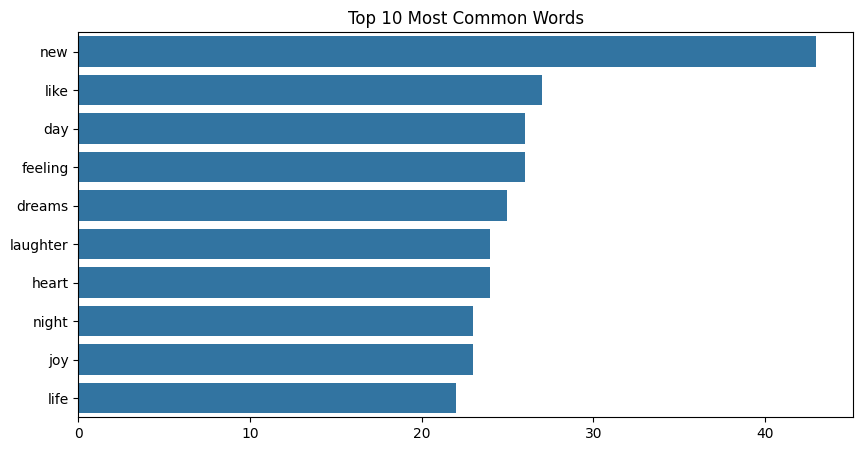

In [ ]:
from collections import Counter

all_words = " ".join(df['Clean_Text']).split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(10)

words = [word[0] for word in common_words]

counts = [word[1] for word in common_words]

plt.figure(figsize=(10,5))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 10 Most Common Words")

plt.show()

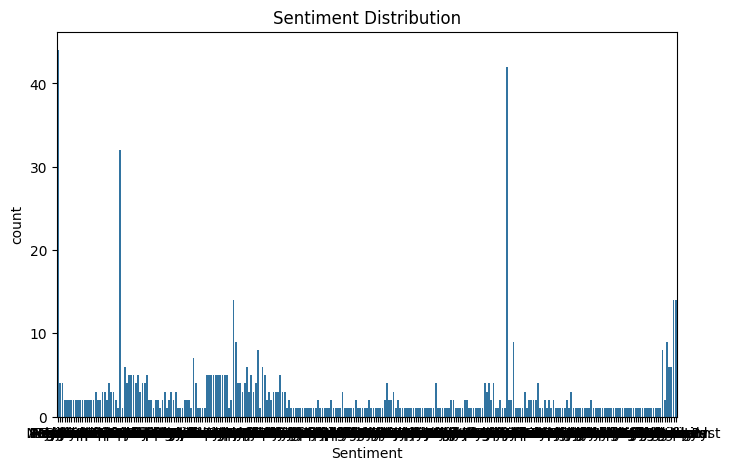

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x='Sentiment', data=df)

plt.title('Sentiment Distribution')

plt.savefig('sentiment_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

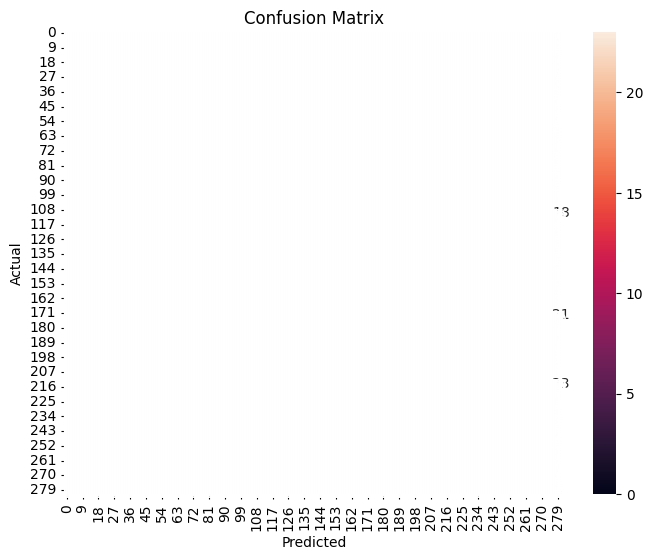

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    df['Sentiment'],
    df['Predicted_Sentiment']
)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

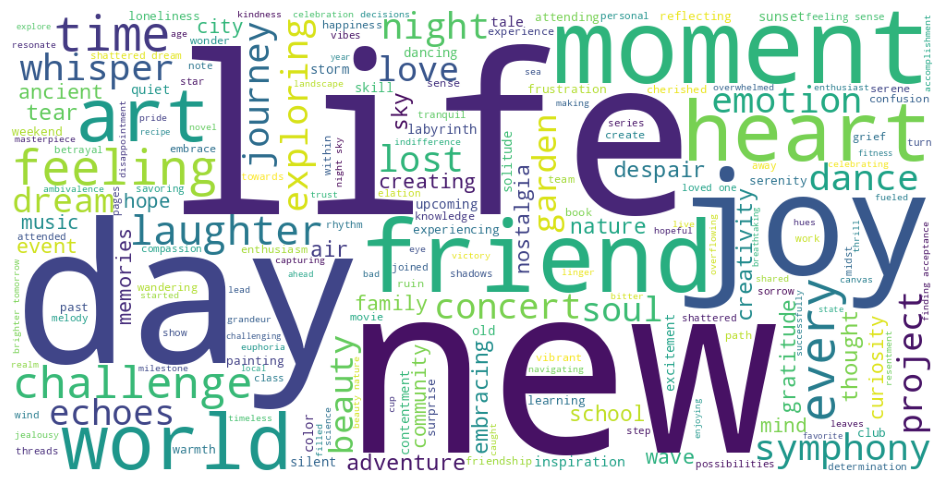

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['Clean_Text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.savefig('wordcloud.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
from google.colab import files

files.download('sentiment_distribution.png')
files.download('confusion_matrix.png')
files.download('wordcloud.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>